# Single tx dataset

In [70]:
import argparse
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Basic sanity checks
    expected_cols = {"metapath", "difference"}
    if not expected_cols.issubset(df.columns):
        raise ValueError(
            f"CSV must contain columns {expected_cols}, found {set(df.columns)}"
        )

    # Ensure 'difference' is numeric
    df["difference"] = pd.to_numeric(df["difference"], errors="coerce")
    if df["difference"].isna().any():
        n_bad = df["difference"].isna().sum()
        print(f"Warning: {n_bad} row(s) had non-numeric 'difference' values and were dropped.")
        df = df.dropna(subset=["difference"])

    return df

df = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment2_lr0.005_dme0.0_es15_202607131112/dme_report.csv")
df["abs_difference"] = df["difference"].abs()

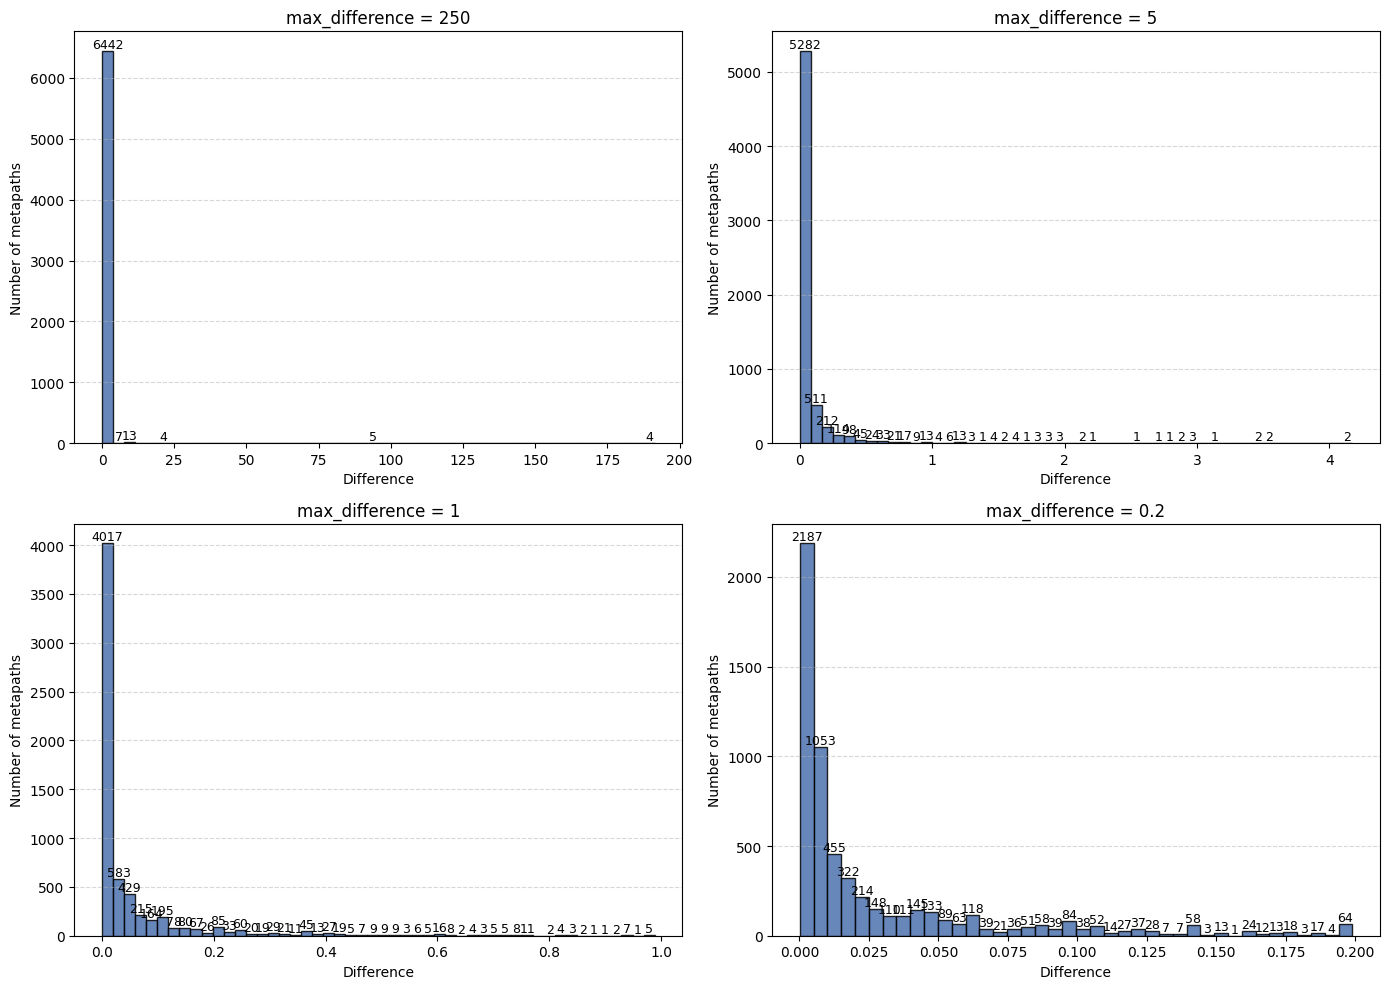

In [71]:
def plot_histogram(df: pd.DataFrame, bins: int, max_difference: float, interval_size: float = None, ax=None, ax_index: int = 0):
    """
    Plot histogram of abs_difference up to max_difference.
    If `interval_size` is provided, bins are calculated as max_difference / interval_size.
    Otherwise, uses the provided bins argument.
    If `ax` is None a new figure/axis is created.
    If `ax` is an array-like of axes (or a numpy.ndarray) the axis at ax_index is used.
    """
    # choose axis
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)
    else:
        # handle numpy.ndarray, list, tuple, or similar containers of Axes
        try:
            # numpy.ndarray has flatten(); use it if available
            if hasattr(ax, "flatten"):
                ax = ax.flatten()[ax_index]
            else:
                ax = ax[ax_index]
        except Exception:
            # if ax is already a single Axes object, leave it
            pass

    # Calculate bins based on interval_size if provided
    if interval_size is not None:
        bins = max(1, int(max_difference / interval_size))

    filtered_df = df[df["abs_difference"] <= max_difference]
    ax.hist(
        filtered_df["abs_difference"],
        bins=bins,
        color="#4C72B0",
        edgecolor="black",
        alpha=0.85,
    )

    ax.set_xlabel("Difference")
    ax.set_ylabel("Number of metapaths")
    ax.set_title(f"max_difference = {max_difference}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate bar counts above each bin
    counts, bin_edges = np.histogram(
        filtered_df["abs_difference"],
        bins=bins,
    )
    for count, left_edge, right_edge in zip(counts, bin_edges[:-1], bin_edges[1:]):
        if count > 0:
            ax.text(
                (left_edge + right_edge) / 2,
                count,
                int(count),
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    return ax

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df, 50, 250, ax=ax, ax_index=0, interval_size=5)
plot_histogram(df, 50, 5, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

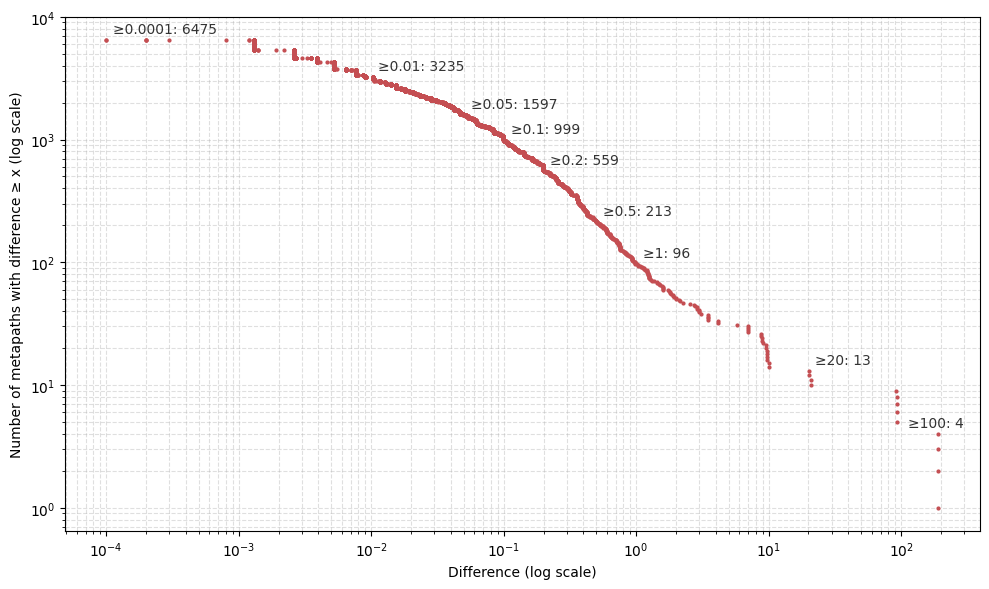

In [99]:
def compute_ccdf(values: np.ndarray):
    """Return (sorted_values, ccdf) where ccdf[i] = count of values >= sorted_values[i]."""
    sorted_vals = np.sort(values)[::-1]  # descending
    n = len(sorted_vals)
    ccdf_counts = np.arange(1, n + 1)  # rank of each value when sorted descending
    return sorted_vals, ccdf_counts
 
 
def plot_ccdf(df: pd.DataFrame, thresholds: list):
    values = df["abs_difference"].to_numpy()
    sorted_vals, ccdf_counts = compute_ccdf(values)
 
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(sorted_vals, ccdf_counts, marker=".", linestyle="none", markersize=4, color="#C44E52")
 
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Difference (log scale)")
    ax.set_ylabel("Number of metapaths with difference \u2265 x (log scale)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    
 
    # Annotate a few reference thresholds if they fall within range
    
    n_total = len(sorted_vals)
    for t in thresholds:
        count_ge_t = int((sorted_vals >= t).sum())
        if count_ge_t > 0:
            ax.annotate(
                f"\u2265{t}: {count_ge_t}",
                xy=(t, count_ge_t),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=10,
                color="#333333",
            )
 
    plt.tight_layout()
 
    # print(f"\nTotal metapaths: {n_total}")
    # print("Reference thresholds:")
    # for t in thresholds:
    #     count_ge_t = int((sorted_vals >= t).sum())
    #     print(f"  difference >= {t:>6}: {count_ge_t}")
    
    return plt.show()

thresholds = [0.0001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 20, 100]
plot_ccdf(df, thresholds)

In [157]:
def min_threshold_for_percentage(df: pd.DataFrame, percentage: float, column: str = "difference") -> float:
    """
    Find the minimum 'difference' threshold t such that at least
    `percentage`% of the metapaths in df have difference >= t.
 
    In other words: what's the lowest bar I can set such that
    `percentage`% of the data still clears it?
 
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the given `column` (default 'difference').
    percentage : float
        Target percentage of metapaths to retain, in (0, 100].
        e.g. 90 -> threshold below which 90% of metapaths remain (difference >= t).
    column : str
        Name of the numeric column to threshold on.
 
    Returns
    -------
    float
        The threshold value t.
    """
    if not (0 < percentage <= 100):
        raise ValueError("percentage must be in the range (0, 100]")
 
    values = df[column].dropna().to_numpy()
    if len(values) == 0:
        raise ValueError(f"No valid values found in column '{column}'")
 
    # We want: count(values >= t) / n >= percentage / 100
    # Equivalently: t is the (100 - percentage)-th percentile of the data,
    # using the "lower" interpolation so the guarantee (>= t) is not violated
    # by interpolated values that don't actually exist in the dataset.
    quantile_point = (100 - percentage) / 100
    threshold = np.quantile(values, quantile_point, method="lower")
 
    return float(threshold)
 
 
def thresholds_for_percentages(df: pd.DataFrame, percentages, column: str = "abs_difference") -> pd.DataFrame:
    """
    Convenience wrapper: compute thresholds for a list of percentages at once.
 
    Returns a DataFrame with columns: percentage, threshold, n_metapaths_retained
    """
    values = df[column].dropna().to_numpy()
    n_total = len(values)
 
    rows = []
    for p in percentages:
        t = min_threshold_for_percentage(df, p, column)
        n_retained = int((values >= t).sum())
        rows.append({
            "percentage": p,
            "threshold": t,
            "n_metapaths_retained": n_retained,
            "pct_actually_retained": round(100 * n_retained / n_total, 2),
        })
 
    return pd.DataFrame(rows)

thresholds_for_percentages(df, [100, 50, 30, 20, 10, 5, 4, 2, 1, 0.5])

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0001,6475,100.00
1,50.0,0.0092,3242,50.07
2,30.0,0.0361,1984,30.64
3,20.0,0.0696,1296,20.02
4,10.0,0.1778,663,10.24
5,5.0,0.3595,343,5.30
6,4.0,0.4149,262,4.05
7,2.0,0.7539,135,2.08
8,1.0,1.4921,66,1.02
9,0.5,3.5061,35,0.54


## Results processing

In [135]:
from pathlib import Path

OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs")

# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 6 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme0.0696_es15_202607132020
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme0.1778_es15_202607132128
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme0.3595_es15_202607132119
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme0.7539_es15_202607131925
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-single-internaltx-clean-ronin2-omni-noma

In [136]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0696_es1...,0.0696,1291,0.199382,1138,0.1977
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1778_es1...,0.1778,663,0.102394,1138,0.1977
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3595_es1...,0.3595,343,0.052973,1138,0.1977
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.7539_es1...,0.7539,136,0.021004,1138,0.1977
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.4921_es1...,1.4921,68,0.010502,1138,0.1977
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme3.5061_es1...,3.5061,37,0.005714,1138,0.1977


In [137]:
def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,test_loss_mean,test_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,pr_auc_mean,pr_auc_std,mcc_mean,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.110933,0.028985,0.955556,8.752415e-03,0.995396,0.003759,0.948905,0.007996,0.971586,...,0.923653,0.026156,0.875202,0.024179,0.911280,1.375455e-02,0.965629,0.010527,0.934799,0.012526
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.116560,0.036057,0.963743,5.729801e-03,0.993973,0.003014,0.960584,0.007444,0.976973,...,0.956864,0.008734,0.894887,0.015113,0.927360,1.090102e-02,0.968527,0.005964,0.945859,0.008048
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.112780,0.028750,0.959064,1.046114e-02,0.995431,0.003732,0.953285,0.011860,0.973866,...,0.940080,0.022851,0.884309,0.027671,0.917986,1.828260e-02,0.967819,0.010210,0.939708,0.014703
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.137487,0.043169,0.962573,4.678363e-03,0.992458,0.000045,0.960584,0.005839,0.976252,...,0.942549,0.017133,0.890793,0.012326,0.926107,9.140896e-03,0.965586,0.002920,0.943983,0.006600
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.129020,0.019362,0.956725,1.019625e-02,0.992400,0.000101,0.953285,0.012727,0.972406,...,0.941521,0.028282,0.876407,0.025290,0.915785,1.821703e-02,0.961936,0.006363,0.936045,0.013906
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.592731,0.013995,0.847953,1.110223e-16,0.844720,0.000000,0.992701,0.000000,0.912752,...,0.499163,0.004495,0.437831,0.000000,0.872360,1.110223e-16,0.628703,0.000000,0.660921,0.000000


In [138]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,339.386,50.903830,1696.93
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,226.856,56.722552,1134.28
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,96.074,31.987378,480.37
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,56.038,9.692464,280.19
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,31.948,10.100753,159.74
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,17.714,3.325914,88.57


In [139]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,mcc_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0696_es1...,0.0696,1291,0.199382,1138,0.1977,0.110933,0.028985,0.955556,...,0.024179,0.911280,1.375455e-02,0.965629,0.010527,0.934799,0.012526,339.386,50.903830,1696.93
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1778_es1...,0.1778,663,0.102394,1138,0.1977,0.116560,0.036057,0.963743,...,0.015113,0.927360,1.090102e-02,0.968527,0.005964,0.945859,0.008048,226.856,56.722552,1134.28
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3595_es1...,0.3595,343,0.052973,1138,0.1977,0.112780,0.028750,0.959064,...,0.027671,0.917986,1.828260e-02,0.967819,0.010210,0.939708,0.014703,96.074,31.987378,480.37
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.7539_es1...,0.7539,136,0.021004,1138,0.1977,0.137487,0.043169,0.962573,...,0.012326,0.926107,9.140896e-03,0.965586,0.002920,0.943983,0.006600,56.038,9.692464,280.19
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.4921_es1...,1.4921,68,0.010502,1138,0.1977,0.129020,0.019362,0.956725,...,0.025290,0.915785,1.821703e-02,0.961936,0.006363,0.936045,0.013906,31.948,10.100753,159.74
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme3.5061_es1...,3.5061,37,0.005714,1138,0.1977,0.592731,0.013995,0.847953,...,0.000000,0.872360,1.110223e-16,0.628703,0.000000,0.660921,0.000000,17.714,3.325914,88.57


In [140]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,0.199382,1291,0.0696,0.955556,8.752415e-03,0.995396,0.003759,0.948905,0.007996,0.971586,...,0.982353,1.440876e-02,0.898013,1.940685e-02,0.946757,0.016159,0.923653,0.026156,339.386,50.903830
1,0.102394,663,0.1778,0.963743,5.729801e-03,0.993973,0.003014,0.960584,0.007444,0.976973,...,0.976471,1.176471e-02,0.914744,1.238607e-02,0.950744,0.009237,0.956864,0.008734,226.856,56.722552
2,0.052973,343,0.3595,0.959064,1.046114e-02,0.995431,0.003732,0.953285,0.011860,0.973866,...,0.982353,1.440876e-02,0.905550,2.261826e-02,0.950009,0.015595,0.940080,0.022851,96.074,31.987378
3,0.021004,136,0.7539,0.962573,4.678363e-03,0.992458,0.000045,0.960584,0.005839,0.976252,...,0.970588,1.110223e-16,0.911715,1.016969e-02,0.946121,0.004357,0.942549,0.017133,56.038,9.692464
4,0.010502,68,1.4921,0.956725,1.019625e-02,0.992400,0.000101,0.953285,0.012727,0.972406,...,0.970588,1.110223e-16,0.899684,2.111902e-02,0.940799,0.009305,0.941521,0.028282,31.948,10.100753
5,0.005714,37,3.5061,0.847953,1.110223e-16,0.844720,0.000000,0.992701,0.000000,0.912752,...,0.264706,0.000000e+00,0.409091,5.551115e-17,0.308219,0.000000,0.499163,0.004495,17.714,3.325914


In [141]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,19.94%,10.24%,5.30%,2.10%,1.05%,0.57%
reported_metapaths,1291,663,343,136,68,37
dme_threshold,0.0696,0.1778,0.3595,0.7539,1.4921,3.5061
accuracy,95.56 ± 00.88,96.37 ± 00.57,95.91 ± 01.05,96.26 ± 00.47,95.67 ± 01.02,84.80 ± 00.00
precision_normal,99.54 ± 00.38,99.40 ± 00.30,99.54 ± 00.37,99.25 ± 00.00,99.24 ± 00.01,84.47 ± 00.00
recall_normal,94.89 ± 00.80,96.06 ± 00.74,95.33 ± 01.19,96.06 ± 00.58,95.33 ± 01.27,99.27 ± 00.00
f1_normal,97.16 ± 00.56,97.70 ± 00.37,97.39 ± 00.68,97.63 ± 00.30,97.24 ± 00.67,91.28 ± 00.00
precision_anomaly,82.72 ± 02.45,86.07 ± 02.23,84.05 ± 03.55,85.98 ± 01.82,83.92 ± 03.63,90.00 ± 00.00
recall_anomaly,98.24 ± 01.44,97.65 ± 01.18,98.24 ± 01.44,97.06 ± 00.00,97.06 ± 00.00,26.47 ± 00.00
f1_anomaly,89.80 ± 01.94,91.47 ± 01.24,90.56 ± 02.26,91.17 ± 01.02,89.97 ± 02.11,40.91 ± 00.00
f2_anomaly,94.68 ± 01.62,95.07 ± 00.92,95.00 ± 01.56,94.61 ± 00.44,94.08 ± 00.93,30.82 ± 00.00


In [142]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (ssec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lcccccc}
\toprule
pct_metapaths & 19.94% & 10.24% & 5.30% & 2.10% & 1.05% & 0.57% \\
\midrule
Reported Metapaths & 1291 & 663 & 343 & 136 & 68 & 37 \\
DME Threshold & 0.0696 & 0.1778 & 0.3595 & 0.7539 & 1.4921 & 3.5061 \\
Accuracy (\%) & $95.56 \pm 00.88$ & $96.37 \pm 00.57$ & $95.91 \pm 01.05$ & $96.26 \pm 00.47$ & $95.67 \pm 01.02$ & $84.80 \pm 00.00$ \\
Precision (Normal) (\%) & $99.54 \pm 00.38$ & $99.40 \pm 00.30$ & $99.54 \pm 00.37$ & $99.25 \pm 00.00$ & $99.24 \pm 00.01$ & $84.47 \pm 00.00$ \\
Recall (Normal) (\%) & $94.89 \pm 00.80$ & $96.06 \pm 00.74$ & $95.33 \pm 01.19$ & $96.06 \pm 00.58$ & $95.33 \pm 01.27$ & $99.27 \pm 00.00$ \\
F1 (Normal) (\%) & $97.16 \pm 00.56$ & $97.70 \pm 00.37$ & $97.39 \pm 00.68$ & $97.63 \pm 00.30$ & $97.24 \pm 00.67$ & $91.28 \pm 00.00$ \\
Precision (Anomaly) (\%) & $82.72 \pm 02.45$ & $86.07 \pm 02.23$ & $84.05 \pm 03.

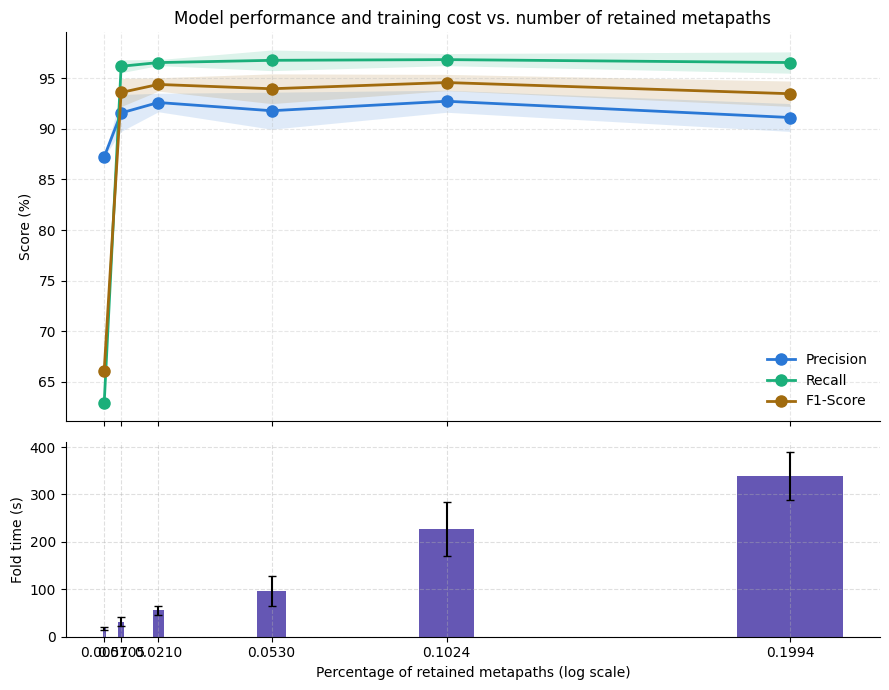

In [143]:
import matplotlib.pyplot as plt

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.set_title("Model performance and training cost vs. number of retained metapaths")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)

# --- Bottom panel: fold training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.bar(
    x, plot_df["fold_time_mean"], width=widths,
    yerr=plot_df["fold_time_std"], capsize=3,
    color=COLOR_TIME, alpha=0.85, edgecolor="none",
)
ax_time.set_ylabel("Fold time (s)")
ax_time.set_xlabel("Percentage of retained metapaths (log scale)")
#ax_time.set_xscale("log")
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

ax_time.xaxis.set_major_locator(FixedLocator(x))

ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("dme_performance_vs_cost.svg", format="svg")
plt.show()


# CCTX Dataset

In [144]:
df2 = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment2_lr0.005_dme0.0_es15_202607131157/dme_report.csv")
df2["abs_difference"] = df2["difference"].abs()

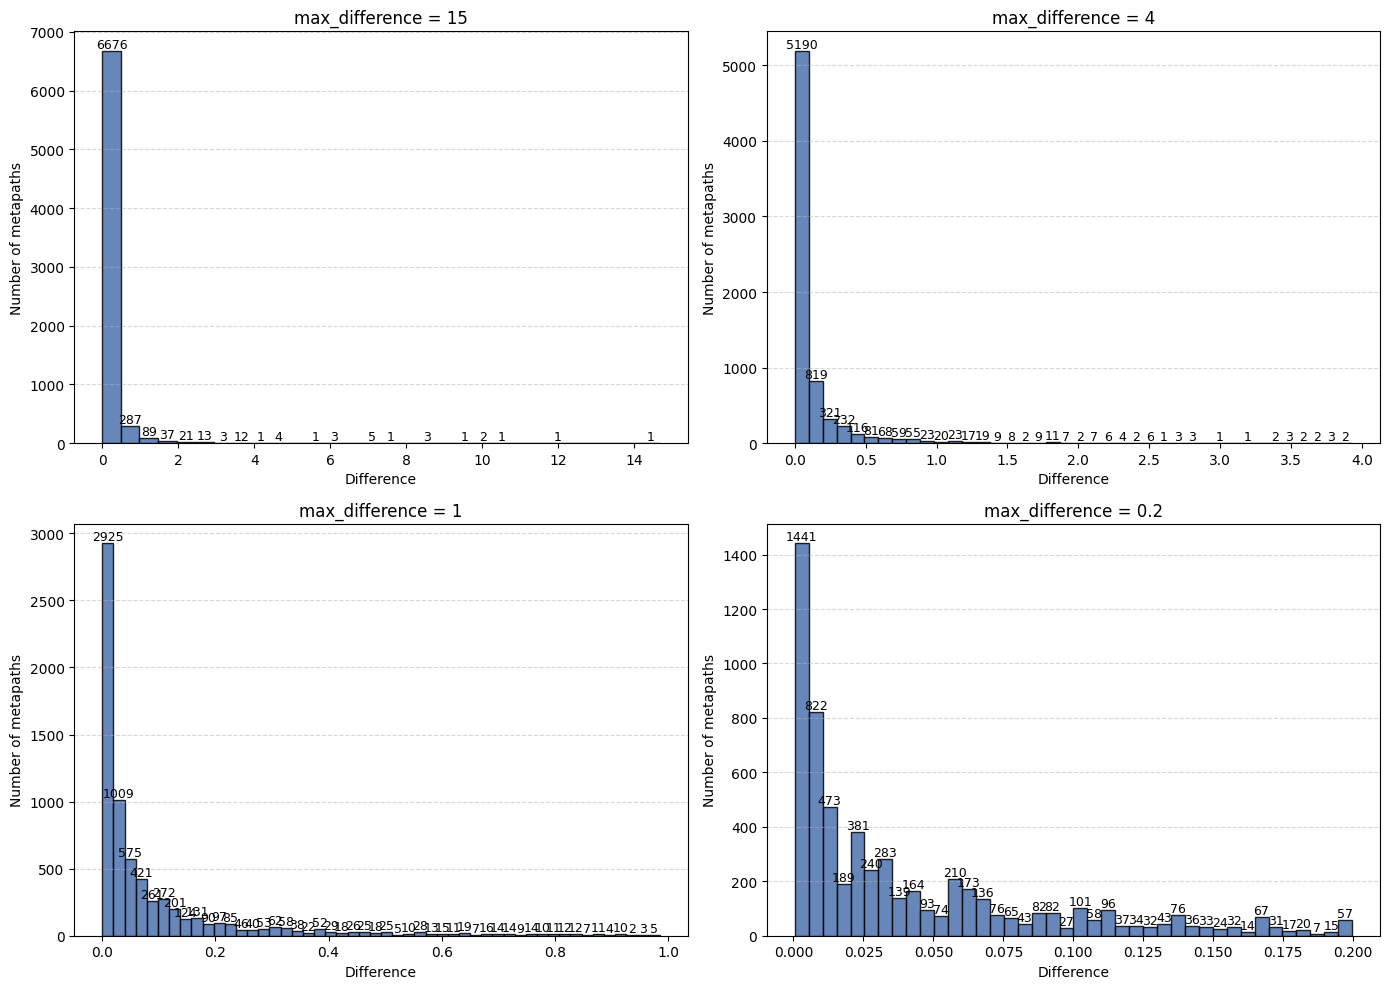

In [145]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df2, 50, 15, ax=ax, ax_index=0, interval_size=0.5)
plot_histogram(df2, 50, 4, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df2, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df2, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

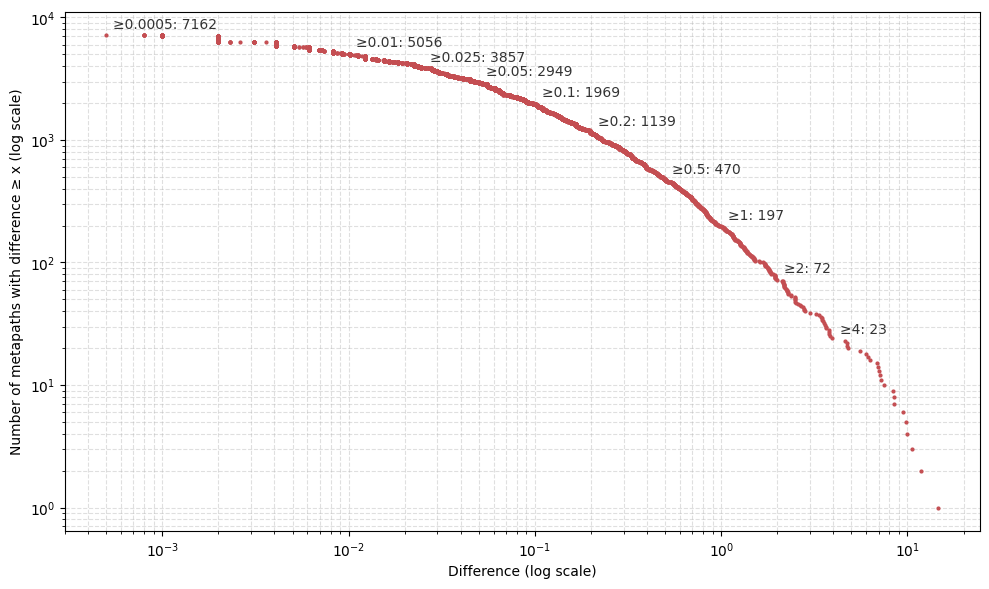

In [146]:
thresholds = [0.0005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1, 2, 4]
plot_ccdf(df2, thresholds)

In [147]:
thresholds_for_percentages(df2, [100, 50, 20, 10, 5, 2, 1, 0.5])

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0005,7162,100.00
1,50.0,0.0307,3616,50.49
2,20.0,0.1484,1438,20.08
3,10.0,0.3316,735,10.26
4,5.0,0.6468,360,5.03
5,2.0,1.2671,145,2.02
6,1.0,1.9795,73,1.02
7,0.5,3.3470,37,0.52


## Results processing

In [148]:
from pathlib import Path

OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs")

# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 5 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme0.3316_es15_202607141112
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme0.6468_es15_202607141057
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme1.2671_es15_202607141049
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qubit-harmony-thor123-meter-ronin1/train_epochs100_augment0_lr0.005_dme1.9795_es15_202607132014
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/20260712-cctx-internaltx-clean-ronin2-omni-nomad-polyn-qu

In [149]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3316_es1...,0.3316,735,0.113514,1233,0.0681
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.6468_es1...,0.6468,360,0.055598,1233,0.0681
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.2671_es1...,1.2671,144,0.022239,1233,0.0681
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.9795_es1...,1.9795,74,0.011429,1233,0.0681
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme3.347_es15...,3.3470,36,0.005560,1233,0.0681


In [150]:
def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    return result

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,test_loss_mean,test_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,mcc_mean,mcc_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.121800,0.118628,0.982703,0.007944,0.996491,0.004662,0.984884,0.006977,0.990636,...,0.886388,0.051203,0.925107,0.052812,0.993739,0.004940,0.914521,0.068456,0.880673,0.054277
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.107090,0.066191,0.980541,0.008783,0.997654,0.002873,0.981395,0.010003,0.989425,...,0.877632,0.049377,0.929397,0.031583,0.994723,0.002143,0.942229,0.014719,0.873317,0.049232
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.248642,0.088621,0.970811,0.007332,0.989425,0.002348,0.979070,0.006977,0.984209,...,0.806984,0.040310,0.838525,0.031766,0.981664,0.013060,0.885503,0.023040,0.793714,0.042107
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.144878,0.072519,0.974054,0.006304,0.992934,0.002315,0.979070,0.006977,0.985937,...,0.832087,0.033267,0.875409,0.025759,0.990698,0.004677,0.888691,0.032988,0.822214,0.033503
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.684739,0.026976,0.929730,0.000000,0.929730,0.000000,1.000000,0.000000,0.963585,...,0.000000,0.000000,0.000000,0.000000,0.634526,0.050916,0.128417,0.047600,0.000000,0.000000


In [151]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,498.694,100.999284,2493.47
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,162.872,49.890627,814.36
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,69.202,20.059856,346.01
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,69.280,25.576296,346.40
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,21.302,2.015752,106.51


In [152]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,f2_anomaly_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,mcc_mean,mcc_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3316_es1...,0.3316,735,0.113514,1233,0.0681,0.121800,0.118628,0.982703,...,0.052812,0.993739,0.004940,0.914521,0.068456,0.880673,0.054277,498.694,100.999284,2493.47
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.6468_es1...,0.6468,360,0.055598,1233,0.0681,0.107090,0.066191,0.980541,...,0.031583,0.994723,0.002143,0.942229,0.014719,0.873317,0.049232,162.872,49.890627,814.36
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.2671_es1...,1.2671,144,0.022239,1233,0.0681,0.248642,0.088621,0.970811,...,0.031766,0.981664,0.013060,0.885503,0.023040,0.793714,0.042107,69.202,20.059856,346.01
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.9795_es1...,1.9795,74,0.011429,1233,0.0681,0.144878,0.072519,0.974054,...,0.025759,0.990698,0.004677,0.888691,0.032988,0.822214,0.033503,69.280,25.576296,346.40
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme3.347_es15...,3.3470,36,0.005560,1233,0.0681,0.684739,0.026976,0.929730,...,0.000000,0.634526,0.050916,0.128417,0.047600,0.000000,0.000000,21.302,2.015752,106.51


In [153]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,0.113514,735,0.3316,0.982703,0.007944,0.996491,0.004662,0.984884,0.006977,0.990636,...,0.953846,0.061538,0.886388,0.051203,0.925107,0.052812,0.914521,0.068456,498.694,100.999284
1,0.055598,360,0.6468,0.980541,0.008783,0.997654,0.002873,0.981395,0.010003,0.989425,...,0.969231,0.037684,0.877632,0.049377,0.929397,0.031583,0.942229,0.014719,162.872,49.890627
2,0.022239,144,1.2671,0.970811,0.007332,0.989425,0.002348,0.979070,0.006977,0.984209,...,0.861538,0.030769,0.806984,0.040310,0.838525,0.031766,0.885503,0.023040,69.202,20.059856
3,0.011429,74,1.9795,0.974054,0.006304,0.992934,0.002315,0.979070,0.006977,0.985937,...,0.907692,0.030769,0.832087,0.033267,0.875409,0.025759,0.888691,0.032988,69.280,25.576296
4,0.005560,36,3.3470,0.929730,0.000000,0.929730,0.000000,1.000000,0.000000,0.963585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.128417,0.047600,21.302,2.015752


In [154]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,11.35%,5.56%,2.22%,1.14%,0.56%
reported_metapaths,735,360,144,74,36
dme_threshold,0.3316,0.6468,1.2671,1.9795,3.3470
accuracy,98.27 ± 00.79,98.05 ± 00.88,97.08 ± 00.73,97.41 ± 00.63,92.97 ± 00.00
precision_normal,99.65 ± 00.47,99.77 ± 00.29,98.94 ± 00.23,99.29 ± 00.23,92.97 ± 00.00
recall_normal,98.49 ± 00.70,98.14 ± 01.00,97.91 ± 00.70,97.91 ± 00.70,100.00 ± 00.00
f1_normal,99.06 ± 00.43,98.94 ± 00.48,98.42 ± 00.40,98.59 ± 00.35,96.36 ± 00.00
precision_anomaly,83.12 ± 06.63,80.69 ± 08.27,76.08 ± 05.72,77.05 ± 05.22,0.00 ± 00.00
recall_anomaly,95.38 ± 06.15,96.92 ± 03.77,86.15 ± 03.08,90.77 ± 03.08,0.00 ± 00.00
f1_anomaly,88.64 ± 05.12,87.76 ± 04.94,80.70 ± 04.03,83.21 ± 03.33,0.00 ± 00.00
f2_anomaly,92.51 ± 05.28,92.94 ± 03.16,83.85 ± 03.18,87.54 ± 02.58,0.00 ± 00.00


In [155]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lccccc}
\toprule
pct_metapaths & 11.35% & 5.56% & 2.22% & 1.14% & 0.56% \\
\midrule
Reported Metapaths & 735 & 360 & 144 & 74 & 36 \\
DME Threshold & 0.3316 & 0.6468 & 1.2671 & 1.9795 & 3.3470 \\
Accuracy (\%) & $98.27 \pm 00.79$ & $98.05 \pm 00.88$ & $97.08 \pm 00.73$ & $97.41 \pm 00.63$ & $92.97 \pm 00.00$ \\
Precision (Normal) (\%) & $99.65 \pm 00.47$ & $99.77 \pm 00.29$ & $98.94 \pm 00.23$ & $99.29 \pm 00.23$ & $92.97 \pm 00.00$ \\
Recall (Normal) (\%) & $98.49 \pm 00.70$ & $98.14 \pm 01.00$ & $97.91 \pm 00.70$ & $97.91 \pm 00.70$ & $100.00 \pm 00.00$ \\
F1 (Normal) (\%) & $99.06 \pm 00.43$ & $98.94 \pm 00.48$ & $98.42 \pm 00.40$ & $98.59 \pm 00.35$ & $96.36 \pm 00.00$ \\
Precision (Anomaly) (\%) & $83.12 \pm 06.63$ & $80.69 \pm 08.27$ & $76.08 \pm 05.72$ & $77.05 \pm 05.22$ & $0.00 \pm 00.00$ \\
Recall (Anomaly) (\%) & $95.38 \pm 06.15$ & $96.92 \pm 03.7